## Import Library

In [1]:
import joblib
import pandas as pd
import numpy as np

import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load Dataset

In [2]:
train_data = pd.read_pickle('../data/preprocess/ready_train_data.pkl')
test_data = pd.read_pickle('../data/preprocess/ready_test_data.pkl')

In [3]:
train_data.head(2)

,smoker_bmi,smoker_bmi_age,smoker_age,smoker_diabetic,nonsmoker_age,nonsmoker_bmi,nonsmoker_bp_age,bloodpressure,health_risk_score,children,claim
1148,26.7,854.4,32.0,1,0.0,0.0,0.0,115,0.5,1,26109.33
807,0.0,0.0,0.0,0,51.0,25.7,4233.0,83,0.0,0,11454.02


## Prepare data

In [4]:
X_train = train_data.drop('claim', axis=1)
y_train = train_data['claim']

X_test = test_data.drop('claim', axis=1)
y_test = test_data['claim']

## Hyperparams

In [5]:
# init model and params
search_space = [
    {
        'name': 'RandomForest',
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 300, 500, 800],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10, 15]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 300, 500, 800],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7, 10],
            'subsample': [0.7, 0.8, 0.9]  
        }
    }
]

## Train model & do cross-validation

In [6]:
# We try to tune the model with the parameters we have defined and do cross validation to check the model performance, not by luck.
tuning_result = []

for s in search_space:
    print(f'Tuning: {s['name']}')
    
    rs = RandomizedSearchCV(
        estimator=s['model'],
        param_distributions=s['params'],
        n_iter=20,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42
    )
    
    rs.fit(X_train, y_train)
    
    tuning_result.append({
        'model': s['name'],
        'bestParams': rs.best_params_,
        'bestTrainMAE': rs.best_score_,
        'bestModel': rs.best_estimator_
    })
    
df_tuning = pd.DataFrame(tuning_result).sort_values(by='bestTrainMAE').reset_index(drop=True)
df_tuning = df_tuning.style.format({'bestTrainMAE': '{:,.2f}'})
display(df_tuning)

Tuning: RandomForest
Tuning: XGBoost


,model,bestParams,bestTrainMAE,bestModel
0,RandomForest,"{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10}","-4,079.46","RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=300, random_state=42)"
1,XGBoost,"{'subsample': 0.7, 'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.01}","-4,076.46","XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=0.01, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=3, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=800, n_jobs=None, num_parallel_tree=None, ...)"


### Test best model with test data

In [7]:
result_test = []

for x in tuning_result:
    model = x['bestModel']
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    result_test.append({
        'model': x['model'],
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

df_test = pd.DataFrame(result_test).sort_values(by='MAE').reset_index(drop=True)
df_test = df_test.style.format({col: '{:,.2f}' for col in ['MAE', 'RMSE', 'R2']})
display(df_test)

,model,MAE,RMSE,R2
0,XGBoost,"3,837.49","5,080.98",0.84
1,RandomForest,"3,938.48","5,269.57",0.83


## Check Feature Importance

In [10]:
models = {r['model']: r['bestModel'] for r in tuning_result}

importance_feature = []

for name, model in models.items():
    importance = model.feature_importances_
    
    feature_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance,
        'Model': name
    }) 
    importance_feature.append(feature_df)
all_importance_feat = pd.concat(importance_feature)

df_importance_pivot = all_importance_feat.pivot(index='Feature', columns='Model', values='Importance')
df_importance_pivot['Average'] = df_importance_pivot.mean(axis=1)
df_top_feat = df_importance_pivot.sort_values(by='Average', ascending=False).head(10)
df_top_feat = df_top_feat.style.format('{:.2f}')
display(df_top_feat)

Model,RandomForest,XGBoost,Average
Feature,,,
smoker_bmi,0.74,0.54,0.64
health_risk_score,0.11,0.33,0.22
bloodpressure,0.07,0.03,0.05
nonsmoker_bp_age,0.02,0.02,0.02
nonsmoker_bmi,0.02,0.01,0.02
children,0.01,0.02,0.02
nonsmoker_age,0.01,0.02,0.01
smoker_bmi_age,0.00,0.01,0.01
smoker_age,0.01,0.01,0.01


### Shap

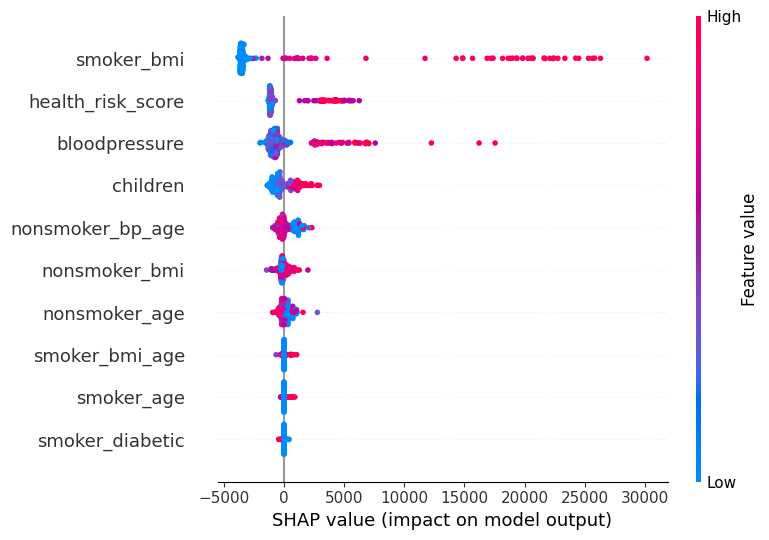

In [11]:
explaner_rf = shap.TreeExplainer(models['RandomForest'])
shap_value_rf = explaner_rf.shap_values(X_test)
shap.summary_plot(shap_value_rf, X_test)

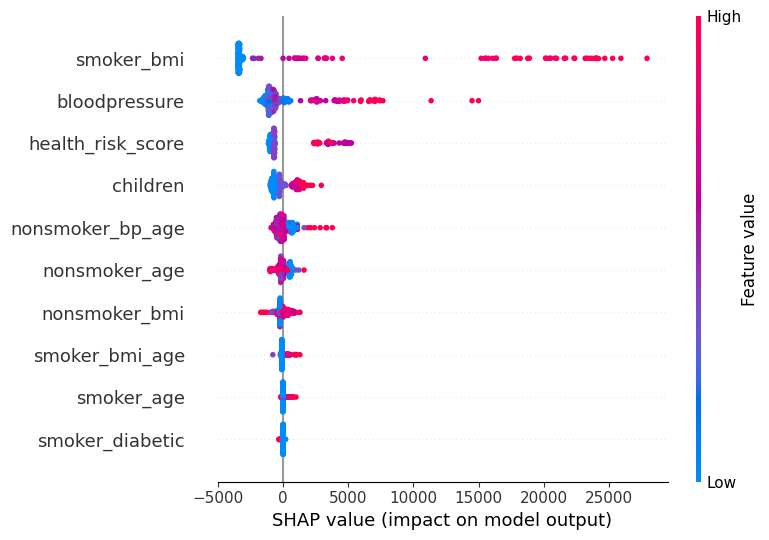

In [13]:
explaner_rf = shap.TreeExplainer(models['XGBoost'])
shap_value_rf = explaner_rf.shap_values(X_test)
shap.summary_plot(shap_value_rf, X_test)

## Save best model

In [8]:
tuning_result[1]['bestModel']

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [9]:
final_model = tuning_result[1]['bestModel']
joblib.dump(final_model, '../model/final_model_xgboost.pkl')

['../model/final_model_xgboost.pkl']